# TSLA Momentum Model — Notebook 2: Backtest Engine

Runs the signals from Notebook 1 through an event-driven backtest: trades execute at the next day's open rather than the signal day's close, positions are sized by a fixed risk-per-trade rule, commissions and slippage are applied, and the stop-loss is checked against the day's low so an intraday breach is not missed.

See `src/backtest.py` for the full mechanics.

In [7]:
import sys
import os

# Resolve the src/ folder regardless of whether the working directory is
# the notebook's own folder (Jupyter/Colab default) or the project root
# (which some IDEs, including PyCharm's Jupyter integration, may use instead).
for _candidate in ("../src", "src"):
    if os.path.isdir(_candidate):
        sys.path.insert(0, _candidate)
        break
else:
    raise RuntimeError(
        "Could not locate the src/ folder from the current working directory: "
        + os.getcwd()
    )

import pandas as pd
import matplotlib.pyplot as plt

from backtest import run_backtest, trades_to_frame

df = pd.read_pickle("tsla_signals.pkl")
df.tail()

Price,open,high,low,close,volume,ema_fast,ema_slow,sma_trend,rsi,atr,volume_avg,regime,raw_entry,raw_exit
date,,,,,,,,,,,,,,
2025-08-25,338.899994,349.529999,335.029999,346.600006,86670000,328.865848,322.800990,311.497000,60.885226,12.902327,78426885.0,True,False,False
2025-08-26,344.929993,351.899994,343.720001,351.670013,76651600,331.037674,323.933109,311.014333,62.973286,12.565017,77891520.0,True,False,False
2025-08-27,351.940002,355.390015,349.160004,349.600006,65519000,332.805515,324.939654,310.577600,61.529076,12.112517,76970875.0,True,False,False
2025-08-28,350.910004,353.549988,340.260010,345.980011,67903200,334.060229,325.764766,310.134933,58.981592,12.196621,76102490.0,True,False,False
2025-08-29,347.230011,348.750000,331.700012,333.869995,81145700,334.042111,326.082618,309.650200,51.325830,12.543290,75703705.0,True,False,False


## Backtest parameters

- **Initial capital:** $100,000
- **Risk per trade:** 1% of current cash, sized by distance from entry to the ATR-based stop
- **Stop distance:** 2.5 × ATR(14) below entry
- **Commission:** $0.005/share, in line with typical US equity retail schedules
- **Slippage:** 5 bps applied to both entries and exits

These are standard assumptions fixed in advance, rather than values selected for their effect on the result.

In [8]:
equity_curve, trades = run_backtest(
    df,
    initial_capital=100_000.0,
    risk_pct=0.01,
    atr_multiplier=2.5,
    commission_per_share=0.005,
    slippage_bps=5.0,
)

trade_log = trades_to_frame(trades)
print(f"Number of trades: {len(trade_log)}")
trade_log

Number of trades: 8


,entry_date,exit_date,entry_price,exit_price,shares,pnl,return_pct,holding_days,exit_reason
0,2017-08-04,2017-10-25,23.144900,22.435443,456,-323.512159,-0.030653,82,signal_exit
1,2018-06-12,2018-07-03,22.991490,20.965891,494,-1000.645923,-0.088102,21,stop_loss
2,2018-08-06,2018-08-17,23.042182,20.506265,390,-989.007344,-0.110055,11,stop_loss
3,2020-04-17,2021-03-08,51.511075,200.083243,105,15600.077590,2.884276,325,signal_exit
4,2021-04-20,2021-05-06,239.259569,226.806538,36,-448.309124,-0.052048,16,signal_exit
5,2022-03-29,2022-04-11,369.514652,326.117285,26,-1128.331534,-0.117444,13,stop_loss
6,2023-05-30,2023-08-21,200.200056,221.439228,59,1253.111145,0.106090,83,signal_exit
7,2025-05-14,2025-06-05,342.671250,296.900476,24,-1098.498571,-0.133571,22,stop_loss


## Equity curve, head and tail

In [9]:
equity_curve.head()

,cash,shares,position_value,equity,buy_hold_equity
date,,,,,
2015-08-07,100000.0,0,0.0,100000.0,97104.239668
2015-08-10,100000.0,0,0.0,100000.0,96555.508666
2015-08-11,100000.0,0,0.0,100000.0,95045.498580
2015-08-12,100000.0,0,0.0,100000.0,95365.924941
2015-08-13,100000.0,0,0.0,100000.0,97104.239668


In [10]:
equity_curve.tail()

,cash,shares,position_value,equity,buy_hold_equity
date,,,,,
2025-08-25,111848.984081,0,0.0,111848.984081,2.082344e+06
2025-08-26,111848.984081,0,0.0,111848.984081,2.112804e+06
2025-08-27,111848.984081,0,0.0,111848.984081,2.100368e+06
2025-08-28,111848.984081,0,0.0,111848.984081,2.078619e+06
2025-08-29,111848.984081,0,0.0,111848.984081,2.005862e+06


## Strategy vs. buy-and-hold

A first-pass visual. Full metrics and the in-sample/out-of-sample check are in Notebook 3.

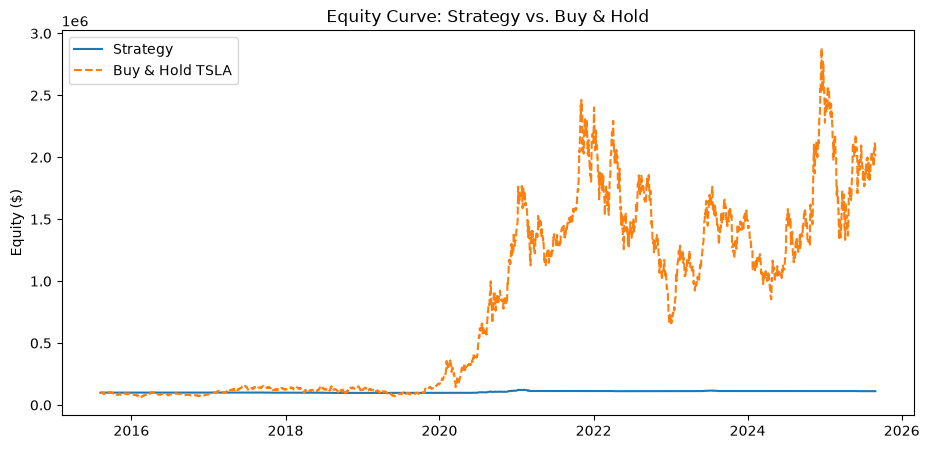

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(equity_curve.index, equity_curve["equity"], label="Strategy")
ax.plot(equity_curve.index, equity_curve["buy_hold_equity"], label="Buy & Hold TSLA", linestyle="--")
ax.set_title("Equity Curve: Strategy vs. Buy & Hold")
ax.set_ylabel("Equity ($)")
ax.legend()
plt.show()

## Interpreting the equity curve

Buy-and-hold TSLA over a long, mostly-rising sample is a demanding benchmark on raw cumulative return, and outperforming it on cumulative return alone is not the objective of a risk-managed strategy. The more informative measures are the risk-adjusted figures (Sharpe and Sortino), drawdown, and the trade-level statistics — covered in Notebook 3 alongside an in-sample/out-of-sample split.

In [12]:
equity_curve.to_pickle("equity_curve.pkl")
trade_log.to_pickle("trade_log.pkl")
print("Saved equity_curve.pkl and trade_log.pkl")

Saved equity_curve.pkl and trade_log.pkl
